In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
water_data = {
    "topic": [
        "Leakage",
        "Bathing",
        "Washing Machine",
        "Gardening",
        "Kitchen",
        "Cleaning",
        "General Water Conservation"
    ],

    "information": [
        "Repair leaking taps, pipes and toilets as soon as possible because leaks can cause continuous water loss.",

        "Reduce shower time and turn off the tap while soaping or shampooing. Use a bucket when appropriate to control water use.",

        "Run the washing machine with full loads when possible. Avoid unnecessary washing cycles.",

        "Water plants during cooler parts of the day and avoid excessive watering. Rainwater can be collected for suitable gardening uses.",

        "Turn off the tap while washing vegetables or dishes when running water is not necessary. Reuse suitable leftover water where practical.",

        "Use a bucket or controlled amount of water for cleaning instead of continuously running a tap or hose.",

        "Monitor household water consumption regularly and identify activities where unnecessary water use occurs."
    ]
}

water_df = pd.DataFrame(water_data)

print("Knowledge base created successfully!")
display(water_df)

Knowledge base created successfully!


,topic,information
0,Leakage,"Repair leaking taps, pipes and toilets as soon..."
1,Bathing,Reduce shower time and turn off the tap while ...
2,Washing Machine,Run the washing machine with full loads when p...
3,Gardening,Water plants during cooler parts of the day an...
4,Kitchen,Turn off the tap while washing vegetables or d...
5,Cleaning,Use a bucket or controlled amount of water for...
6,General Water Conservation,Monitor household water consumption regularly ...


In [3]:
vectorizer = TfidfVectorizer(stop_words="english")

knowledge_vectors = vectorizer.fit_transform(
    water_df["information"]
)

print("Knowledge base converted into searchable vectors.")

Knowledge base converted into searchable vectors.


In [4]:
def retrieve_water_advice(user_query, top_n=3):

    query_vector = vectorizer.transform([user_query])

    similarity_scores = cosine_similarity(
        query_vector,
        knowledge_vectors
    ).flatten()

    top_indices = similarity_scores.argsort()[-top_n:][::-1]

    results = water_df.iloc[top_indices].copy()
    results["similarity_score"] = similarity_scores[top_indices]

    return results

In [5]:
user_query = "My house has a leaking tap and we are wasting water."

results = retrieve_water_advice(user_query)

display(results)

,topic,information,similarity_score
0,Leakage,"Repair leaking taps, pipes and toilets as soon...",0.282131
4,Kitchen,Turn off the tap while washing vegetables or d...,0.227758
5,Cleaning,Use a bucket or controlled amount of water for...,0.200981


In [6]:
def calculate_water_usage(
    people,
    daily_usage,
    bathing,
    washing_machine,
    gardening,
    leakage
):

    per_person_usage = daily_usage / people

    print("========== WATER USAGE ANALYSIS ==========")
    print(f"Number of people: {people}")
    print(f"Estimated daily usage: {daily_usage} litres")
    print(f"Estimated usage per person: {per_person_usage:.2f} litres/day")
    print()

    if leakage:
        print("⚠️ Leakage detected: Check taps, pipes and toilets.")

    if bathing:
        print("💧 Bathing: Consider reducing unnecessary water flow.")

    if washing_machine:
        print("🧺 Washing machine: Prefer full-load washing when possible.")

    if gardening:
        print("🌱 Gardening: Avoid excessive watering and consider suitable rainwater use.")

In [8]:
calculate_water_usage(
    people=4,
    daily_usage=600,
    bathing=True,
    washing_machine=True,
    gardening=True,
    leakage=True
)

========== WATER USAGE ANALYSIS ==========
Number of people: 4
Estimated daily usage: 600 litres
Estimated usage per person: 150.00 litres/day

⚠️ Leakage detected: Check taps, pipes and toilets.
💧 Bathing: Consider reducing unnecessary water flow.
🧺 Washing machine: Prefer full-load washing when possible.
🌱 Gardening: Avoid excessive watering and consider suitable rainwater use.


In [10]:
def smart_water_advisor(
    people,
    daily_usage,
    activities,
    concerns
):

    print("\n" + "="*60)
    print("       💧 SMART WATER USAGE ADVISOR")
    print("="*60)

    print(f"\n👥 People in household: {people}")
    print(f"💧 Estimated daily water usage: {daily_usage} litres")

    per_person = daily_usage / people

    print(f"📊 Estimated usage per person: {per_person:.2f} litres/day")

    print("\n🔎 Identified activities:")
    for activity in activities:
        print(f"   • {activity}")

    print("\n⚠️ Reported concerns:")
    for concern in concerns:
        print(f"   • {concern}")

    # Combine activities and concerns for retrieval
    user_query = " ".join(activities + concerns)

    results = retrieve_water_advice(user_query, top_n=3)

    print("\n💡 PERSONALIZED WATER-SAVING RECOMMENDATIONS")
    print("-"*60)

    for _, row in results.iterrows():
        print(f"\n🔹 {row['topic']}")
        print(f"   {row['information']}")

    print("\n" + "="*60)
    print("SDG ALIGNMENT: SDG 6 - Clean Water and Sanitation")
    print("="*60)

In [11]:
smart_water_advisor(
    people=4,
    daily_usage=600,

    activities=[
        "bathing",
        "washing machine",
        "gardening"
    ],

    concerns=[
        "water leakage",
        "high water consumption"
    ]
)


       💧 SMART WATER USAGE ADVISOR

👥 People in household: 4
💧 Estimated daily water usage: 600 litres
📊 Estimated usage per person: 150.00 litres/day

🔎 Identified activities:
   • bathing
   • washing machine
   • gardening

⚠️ Reported concerns:
   • water leakage
   • high water consumption

💡 PERSONALIZED WATER-SAVING RECOMMENDATIONS
------------------------------------------------------------

🔹 Washing Machine
   Run the washing machine with full loads when possible. Avoid unnecessary washing cycles.

🔹 General Water Conservation
   Monitor household water consumption regularly and identify activities where unnecessary water use occurs.

🔹 Kitchen
   Turn off the tap while washing vegetables or dishes when running water is not necessary. Reuse suitable leftover water where practical.

SDG ALIGNMENT: SDG 6 - Clean Water and Sanitation


In [12]:
smart_water_advisor(
    people=3,
    daily_usage=450,

    activities=[
        "bathing",
        "kitchen"
    ],

    concerns=[
        "tap water wastage"
    ]
)


       💧 SMART WATER USAGE ADVISOR

👥 People in household: 3
💧 Estimated daily water usage: 450 litres
📊 Estimated usage per person: 150.00 litres/day

🔎 Identified activities:
   • bathing
   • kitchen

⚠️ Reported concerns:
   • tap water wastage

💡 PERSONALIZED WATER-SAVING RECOMMENDATIONS
------------------------------------------------------------

🔹 Kitchen
   Turn off the tap while washing vegetables or dishes when running water is not necessary. Reuse suitable leftover water where practical.

🔹 Cleaning
   Use a bucket or controlled amount of water for cleaning instead of continuously running a tap or hose.

🔹 Bathing
   Reduce shower time and turn off the tap while soaping or shampooing. Use a bucket when appropriate to control water use.

SDG ALIGNMENT: SDG 6 - Clean Water and Sanitation


In [13]:
smart_water_advisor(
    people=6,
    daily_usage=1000,

    activities=[
        "gardening",
        "washing machine",
        "cleaning"
    ],

    concerns=[
        "excessive water usage"
    ]
)


       💧 SMART WATER USAGE ADVISOR

👥 People in household: 6
💧 Estimated daily water usage: 1000 litres
📊 Estimated usage per person: 166.67 litres/day

🔎 Identified activities:
   • gardening
   • washing machine
   • cleaning

⚠️ Reported concerns:
   • excessive water usage

💡 PERSONALIZED WATER-SAVING RECOMMENDATIONS
------------------------------------------------------------

🔹 Washing Machine
   Run the washing machine with full loads when possible. Avoid unnecessary washing cycles.

🔹 Gardening
   Water plants during cooler parts of the day and avoid excessive watering. Rainwater can be collected for suitable gardening uses.

🔹 Cleaning
   Use a bucket or controlled amount of water for cleaning instead of continuously running a tap or hose.

SDG ALIGNMENT: SDG 6 - Clean Water and Sanitation


In [14]:
smart_water_advisor(
    people=2,
    daily_usage=300,

    activities=[
        "bathing",
        "cleaning"
    ],

    concerns=[
        "leaking pipe"
    ]
)


       💧 SMART WATER USAGE ADVISOR

👥 People in household: 2
💧 Estimated daily water usage: 300 litres
📊 Estimated usage per person: 150.00 litres/day

🔎 Identified activities:
   • bathing
   • cleaning

⚠️ Reported concerns:
   • leaking pipe

💡 PERSONALIZED WATER-SAVING RECOMMENDATIONS
------------------------------------------------------------

🔹 Cleaning
   Use a bucket or controlled amount of water for cleaning instead of continuously running a tap or hose.

🔹 Leakage
   Repair leaking taps, pipes and toilets as soon as possible because leaks can cause continuous water loss.

🔹 General Water Conservation
   Monitor household water consumption regularly and identify activities where unnecessary water use occurs.

SDG ALIGNMENT: SDG 6 - Clean Water and Sanitation


In [15]:
def analyze_water_usage(people, daily_usage):

    per_person = daily_usage / people

    if per_person < 100:
        category = "Low Water Usage"
        message = "Your estimated water usage is relatively low."

    elif per_person <= 150:
        category = "Moderate Water Usage"
        message = "Your estimated water usage is within a moderate range. There may still be opportunities to save water."

    else:
        category = "High Water Usage"
        message = "Your estimated water usage is relatively high. Consider reducing unnecessary water consumption."

    return per_person, category, message

In [17]:
def generate_recommendations(activities, concerns):

    recommendations = []

    text = " ".join(activities + concerns).lower()

    if "leak" in text or "leakage" in text:
        recommendations.append(
            "Check and repair leaking taps, pipes and toilets as soon as possible."
        )

    if "bathing" in text or "shower" in text:
        recommendations.append(
            "Reduce shower time and avoid keeping the tap running unnecessarily."
        )

    if "washing machine" in text or "laundry" in text:
        recommendations.append(
            "Use the washing machine with full loads when possible to reduce unnecessary water use."
        )

    if "gardening" in text or "garden" in text:
        recommendations.append(
            "Avoid excessive watering and consider watering plants during cooler parts of the day."
        )

    if "kitchen" in text or "dish" in text:
        recommendations.append(
            "Turn off the tap when continuous running water is not necessary during kitchen activities."
        )

    if "cleaning" in text:
        recommendations.append(
            "Use a controlled amount of water for cleaning instead of continuously running a tap or hose."
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Monitor your daily water consumption and identify activities where water can be saved."
        )

    return recommendations

In [18]:
def final_water_advisor(
    people,
    daily_usage,
    activities,
    concerns
):

    per_person, category, message = analyze_water_usage(
        people,
        daily_usage
    )

    recommendations = generate_recommendations(
        activities,
        concerns
    )

    print("\n" + "=" * 65)
    print("             SMART WATER USAGE ADVISOR")
    print("=" * 65)

    print("\nWATER USAGE ANALYSIS")
    print("-" * 65)

    print(f"Number of people       : {people}")
    print(f"Estimated daily usage  : {daily_usage} litres")
    print(f"Usage per person       : {per_person:.2f} litres/day")
    print(f"Usage category         : {category}")

    print(f"\n{message}")

    print("\nACTIVITIES")
    print("-" * 65)

    for activity in activities:
        print("•", activity)

    print("\nCONCERNS")
    print("-" * 65)

    for concern in concerns:
        print("•", concern)

    print("\nPERSONALIZED WATER-SAVING RECOMMENDATIONS")
    print("-" * 65)

    for i, recommendation in enumerate(recommendations, 1):
        print(f"{i}. {recommendation}")

    print("\nSUSTAINABILITY ALIGNMENT")
    print("-" * 65)
    print("SDG 6 - Clean Water and Sanitation")

    print("\nAI APPROACH")
    print("-" * 65)
    print("Information retrieval + personalized recommendation")

    print("\n" + "=" * 65)

In [19]:
final_water_advisor(
    people=4,
    daily_usage=600,

    activities=[
        "bathing",
        "washing machine",
        "gardening"
    ],

    concerns=[
        "water leakage",
        "high water consumption"
    ]
)


             SMART WATER USAGE ADVISOR

WATER USAGE ANALYSIS
-----------------------------------------------------------------
Number of people       : 4
Estimated daily usage  : 600 litres
Usage per person       : 150.00 litres/day
Usage category         : Moderate Water Usage

Your estimated water usage is within a moderate range. There may still be opportunities to save water.

ACTIVITIES
-----------------------------------------------------------------
• bathing
• washing machine
• gardening

CONCERNS
-----------------------------------------------------------------
• water leakage
• high water consumption

PERSONALIZED WATER-SAVING RECOMMENDATIONS
-----------------------------------------------------------------
1. Check and repair leaking taps, pipes and toilets as soon as possible.
2. Reduce shower time and avoid keeping the tap running unnecessarily.
3. Use the washing machine with full loads when possible to reduce unnecessary water use.
4. Avoid excessive watering and consid

In [20]:
!pip -q install gradio

In [21]:
import gradio as gr

print("Gradio imported successfully!")

Gradio imported successfully!


In [23]:
def advisor_interface(people, daily_usage, activities, concerns):

    # Convert text into lists
    activities_list = [
        x.strip()
        for x in activities.split(",")
        if x.strip()
    ]

    concerns_list = [
        x.strip()
        for x in concerns.split(",")
        if x.strip()
    ]

    # Analyze water usage
    per_person, category, message = analyze_water_usage(
        people,
        daily_usage
    )

    # Generate recommendations
    recommendations = generate_recommendations(
        activities_list,
        concerns_list
    )

    # Create final report
    output = f"""
# 💧 Smart Water Usage Advisor

## 📊 Water Usage Analysis

**Number of People:** {people}

**Estimated Daily Water Usage:** {daily_usage} litres

**Estimated Usage Per Person:** {per_person:.2f} litres/day

**Usage Category:** {category}

### Analysis

{message}

---

## 🔎 Water-Using Activities

{", ".join(activities_list)}

---

## ⚠️ Water-Related Concerns

{", ".join(concerns_list)}

---

## 💡 Personalized Water-Saving Recommendations
"""

    for i, recommendation in enumerate(recommendations, 1):
        output += f"\n**{i}.** {recommendation}\n"

    output += """
---

## 🌱 Sustainability Alignment

**SDG 6 – Clean Water and Sanitation**

The advisor promotes responsible and sustainable water consumption.
"""

    return output

In [24]:
with gr.Blocks() as app:

    gr.Markdown(
        """
        # 💧 Smart Water Usage Advisor

        ### AI-based decision-support system for sustainable water consumption

        Enter your household water-use information below.
        """
    )

    people = gr.Number(
        label="Number of People",
        value=4
    )

    daily_usage = gr.Number(
        label="Estimated Daily Water Usage (Litres)",
        value=600
    )

    activities = gr.Textbox(
        label="Water-Using Activities",
        placeholder="Example: bathing, gardening, washing machine"
    )

    concerns = gr.Textbox(
        label="Water-Related Concerns",
        placeholder="Example: leakage, excessive usage"
    )

    button = gr.Button(
        "💧 Analyze Water Usage"
    )

    output = gr.Markdown()

    button.click(
        fn=advisor_interface,
        inputs=[
            people,
            daily_usage,
            activities,
            concerns
        ],
        outputs=output
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d781bc228b4c8facef.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
import matplotlib.pyplot as plt

print("Matplotlib imported successfully!")

Matplotlib imported successfully!


In [26]:


def visualize_water_usage(people, daily_usage):
    per_person = daily_usage / people

    labels = [
        "Total Daily Usage",
        "Usage Per Person"
    ]

    values = [
        daily_usage,
        per_person
    ]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)

    plt.title("Household Water Usage Analysis")
    plt.xlabel("Water Usage Measure")
    plt.ylabel("Water Usage (Litres)")

    plt.tight_layout()
    plt.show()

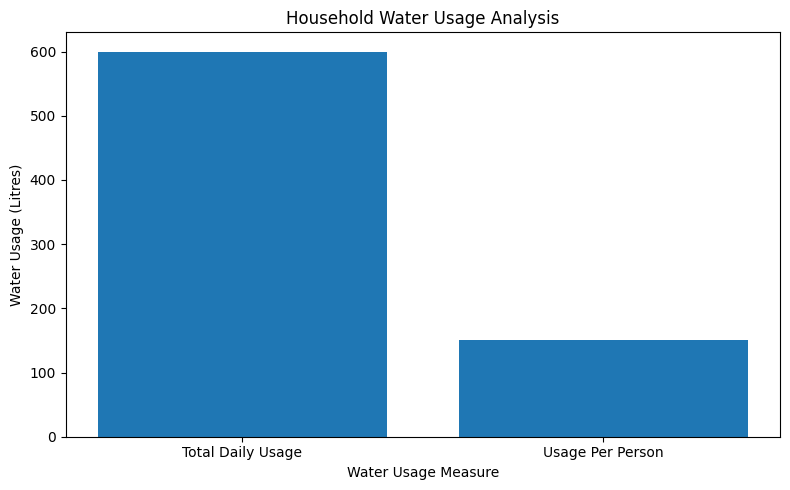

In [27]:


visualize_water_usage(
    people=4,
    daily_usage=600
)

In [29]:


def visualize_activities(activities):
    activity_names = list(activities.keys())
    usage_values = list(activities.values())

    plt.figure(figsize=(9, 5))
    plt.bar(activity_names, usage_values)

    plt.title("Estimated Water Usage by Activity")
    plt.xlabel("Water-Using Activity")
    plt.ylabel("Estimated Water Usage (Litres)")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [30]:


activities = {
    "Bathing": 200,
    "Washing Machine": 120,
    "Gardening": 100,
    "Kitchen": 80,
    "Cleaning": 100
}

print("Activity data created successfully!")

Activity data created successfully!


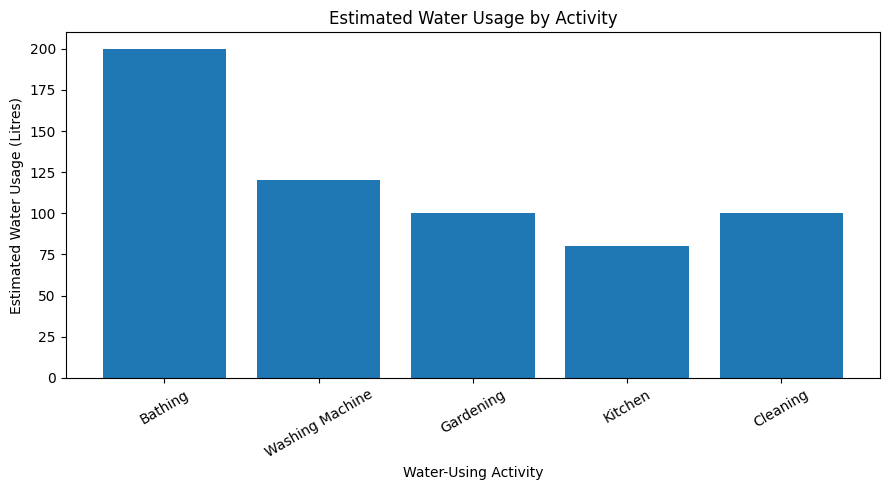

In [31]:
visualize_activities(activities)

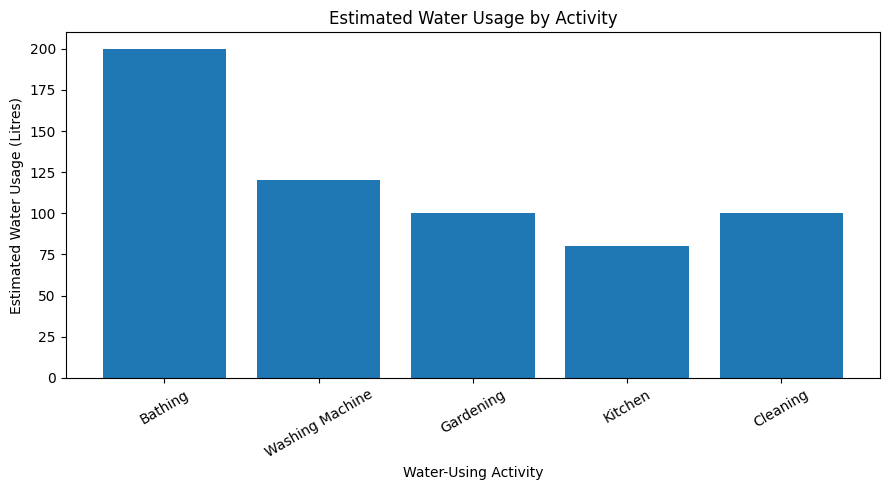

Chart saved successfully!


In [32]:


plt.figure(figsize=(9, 5))

plt.bar(
    activities.keys(),
    activities.values()
)

plt.title("Estimated Water Usage by Activity")
plt.xlabel("Water-Using Activity")
plt.ylabel("Estimated Water Usage (Litres)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("water_usage_activity_chart.png", dpi=300)

plt.show()

print("Chart saved successfully!")

In [33]:
# STEP 11 - Responsible AI Considerations

responsible_ai = {
    "Transparency":
        "The advisor explains why a recommendation is provided based on the user's water usage information.",

    "Privacy":
        "The prototype uses user-provided household information only for generating recommendations and does not require sensitive personal information.",

    "Fairness":
        "Recommendations are based on the information entered by the user and should not discriminate against users based on personal characteristics.",

    "Accuracy":
        "The recommendations are general water-saving suggestions and should be treated as guidance rather than exact measurements.",

    "Human Oversight":
        "Users should review the recommendations and make their own decisions based on their actual water usage and circumstances."
}

print("Responsible AI considerations created successfully!")

Responsible AI considerations created successfully!


In [34]:
# STEP 11 - Display Responsible AI Considerations

print("\n" + "=" * 70)
print("             RESPONSIBLE AI CONSIDERATIONS")
print("=" * 70)

for principle, explanation in responsible_ai.items():
    print(f"\n{principle}")
    print("-" * 70)
    print(explanation)

print("\n" + "=" * 70)


             RESPONSIBLE AI CONSIDERATIONS

Transparency
----------------------------------------------------------------------
The advisor explains why a recommendation is provided based on the user's water usage information.

Privacy
----------------------------------------------------------------------
The prototype uses user-provided household information only for generating recommendations and does not require sensitive personal information.

Fairness
----------------------------------------------------------------------
Recommendations are based on the information entered by the user and should not discriminate against users based on personal characteristics.

Accuracy
----------------------------------------------------------------------
The recommendations are general water-saving suggestions and should be treated as guidance rather than exact measurements.

Human Oversight
----------------------------------------------------------------------
Users should review the recommend

In [35]:
# STEP 12 - Test Case 1: Water Leakage

print("TEST CASE 1 - WATER LEAKAGE")

final_water_advisor(
    people=4,
    daily_usage=600,
    activities=[
        "bathing",
        "washing machine"
    ],
    concerns=[
        "water leakage",
        "high water consumption"
    ]
)


TEST CASE 1 - WATER LEAKAGE

             SMART WATER USAGE ADVISOR

WATER USAGE ANALYSIS
-----------------------------------------------------------------
Number of people       : 4
Estimated daily usage  : 600 litres
Usage per person       : 150.00 litres/day
Usage category         : Moderate Water Usage

Your estimated water usage is within a moderate range. There may still be opportunities to save water.

ACTIVITIES
-----------------------------------------------------------------
• bathing
• washing machine

CONCERNS
-----------------------------------------------------------------
• water leakage
• high water consumption

PERSONALIZED WATER-SAVING RECOMMENDATIONS
-----------------------------------------------------------------
1. Check and repair leaking taps, pipes and toilets as soon as possible.
2. Reduce shower time and avoid keeping the tap running unnecessarily.
3. Use the washing machine with full loads when possible to reduce unnecessary water use.

SUSTAINABILITY ALIGNM

In [36]:
# STEP 12 - Test Case 2: Gardening

print("TEST CASE 2 - GARDENING")

final_water_advisor(
    people=3,
    daily_usage=450,
    activities=[
        "gardening",
        "bathing"
    ],
    concerns=[
        "excessive water usage"
    ]
)


TEST CASE 2 - GARDENING

             SMART WATER USAGE ADVISOR

WATER USAGE ANALYSIS
-----------------------------------------------------------------
Number of people       : 3
Estimated daily usage  : 450 litres
Usage per person       : 150.00 litres/day
Usage category         : Moderate Water Usage

Your estimated water usage is within a moderate range. There may still be opportunities to save water.

ACTIVITIES
-----------------------------------------------------------------
• gardening
• bathing

CONCERNS
-----------------------------------------------------------------
• excessive water usage

PERSONALIZED WATER-SAVING RECOMMENDATIONS
-----------------------------------------------------------------
1. Reduce shower time and avoid keeping the tap running unnecessarily.
2. Avoid excessive watering and consider watering plants during cooler parts of the day.

SUSTAINABILITY ALIGNMENT
-----------------------------------------------------------------
SDG 6 - Clean Water and Sanitat

In [37]:
# STEP 12 - Test Case 3: Kitchen and Cleaning

print("TEST CASE 3 - KITCHEN AND CLEANING")

final_water_advisor(
    people=5,
    daily_usage=800,
    activities=[
        "kitchen",
        "cleaning"
    ],
    concerns=[
        "high water consumption"
    ]
)

TEST CASE 3 - KITCHEN AND CLEANING

             SMART WATER USAGE ADVISOR

WATER USAGE ANALYSIS
-----------------------------------------------------------------
Number of people       : 5
Estimated daily usage  : 800 litres
Usage per person       : 160.00 litres/day
Usage category         : High Water Usage

Your estimated water usage is relatively high. Consider reducing unnecessary water consumption.

ACTIVITIES
-----------------------------------------------------------------
• kitchen
• cleaning

CONCERNS
-----------------------------------------------------------------
• high water consumption

PERSONALIZED WATER-SAVING RECOMMENDATIONS
-----------------------------------------------------------------
1. Turn off the tap when continuous running water is not necessary during kitchen activities.
2. Use a controlled amount of water for cleaning instead of continuously running a tap or hose.

SUSTAINABILITY ALIGNMENT
-----------------------------------------------------------------
S

In [38]:
# STEP 12 - Test Case 4: General Water Conservation

print("TEST CASE 4 - GENERAL WATER CONSERVATION")

final_water_advisor(
    people=2,
    daily_usage=250,
    activities=[
        "daily household activities"
    ],
    concerns=[
        "no specific concern"
    ]
)

TEST CASE 4 - GENERAL WATER CONSERVATION

             SMART WATER USAGE ADVISOR

WATER USAGE ANALYSIS
-----------------------------------------------------------------
Number of people       : 2
Estimated daily usage  : 250 litres
Usage per person       : 125.00 litres/day
Usage category         : Moderate Water Usage

Your estimated water usage is within a moderate range. There may still be opportunities to save water.

ACTIVITIES
-----------------------------------------------------------------
• daily household activities

CONCERNS
-----------------------------------------------------------------
• no specific concern

PERSONALIZED WATER-SAVING RECOMMENDATIONS
-----------------------------------------------------------------
1. Monitor your daily water consumption and identify activities where water can be saved.

SUSTAINABILITY ALIGNMENT
-----------------------------------------------------------------
SDG 6 - Clean Water and Sanitation

AI APPROACH
-------------------------------

In [39]:
# STEP 12 - Testing Summary

test_results = {
    "Test Case 1": "Leakage recommendations generated",
    "Test Case 2": "Gardening recommendations generated",
    "Test Case 3": "Kitchen and cleaning recommendations generated",
    "Test Case 4": "General conservation recommendation generated"
}

print("\n" + "=" * 65)
print("                 TESTING SUMMARY")
print("=" * 65)

for test_case, result in test_results.items():
    print(f"\n{test_case}:")
    print(f"✓ {result}")

print("\n" + "=" * 65)
print("Prototype testing completed successfully.")
print("=" * 65)


                 TESTING SUMMARY

Test Case 1:
✓ Leakage recommendations generated

Test Case 2:
✓ Gardening recommendations generated

Test Case 3:
✓ Kitchen and cleaning recommendations generated

Test Case 4:
✓ General conservation recommendation generated

Prototype testing completed successfully.


In [40]:
# STEP 13 - Project Summary

project_summary = {
    "Project Title": "AI-Based Smart Water Usage Advisor",
    "SDG": "SDG 6 - Clean Water and Sanitation",
    "Problem": "Inefficient water consumption and lack of personalized water-saving guidance",
    "Solution": "A Python-based decision-support prototype that analyzes user inputs and provides personalized water-saving recommendations",
    "AI Approach": "TF-IDF information retrieval and personalized recommendation",
    "Target Users": "Households, students, residential communities, educational institutions, and individuals",
    "Interface": "Interactive Gradio web interface"
}

print("\n" + "=" * 70)
print("                  PROJECT SUMMARY")
print("=" * 70)

for key, value in project_summary.items():
    print(f"\n{key}:")
    print(value)

print("\n" + "=" * 70)


                  PROJECT SUMMARY

Project Title:
AI-Based Smart Water Usage Advisor

SDG:
SDG 6 - Clean Water and Sanitation

Problem:
Inefficient water consumption and lack of personalized water-saving guidance

Solution:
A Python-based decision-support prototype that analyzes user inputs and provides personalized water-saving recommendations

AI Approach:
TF-IDF information retrieval and personalized recommendation

Target Users:
Households, students, residential communities, educational institutions, and individuals

Interface:
Interactive Gradio web interface



In [41]:
# STEP 13 - Expected Impact

impact = [
    "Increase awareness about responsible water consumption.",
    "Help users identify activities where water can potentially be saved.",
    "Provide simple and personalized water-saving recommendations.",
    "Encourage sustainable water-use habits.",
    "Support the objective of SDG 6 - Clean Water and Sanitation."
]

print("\n" + "=" * 70)
print("                    EXPECTED IMPACT")
print("=" * 70)

for i, item in enumerate(impact, 1):
    print(f"{i}. {item}")

print("\n" + "=" * 70)


                    EXPECTED IMPACT
1. Increase awareness about responsible water consumption.
2. Help users identify activities where water can potentially be saved.
3. Provide simple and personalized water-saving recommendations.
4. Encourage sustainable water-use habits.
5. Support the objective of SDG 6 - Clean Water and Sanitation.



In [42]:
# STEP 14 - Final Project Checklist

checklist = {
    "Problem Statement": "DONE",
    "SDG Alignment": "DONE - SDG 6",
    "Knowledge Base": "DONE",
    "Information Retrieval": "DONE",
    "Water Usage Analysis": "DONE",
    "Personalized Recommendations": "DONE",
    "RAG Demonstration": "DONE",
    "Interactive Gradio Prototype": "DONE",
    "Visualization": "DONE",
    "Responsible AI": "DONE",
    "Testing": "DONE",
    "Expected Impact": "DONE"
}

print("\n" + "=" * 70)
print("                 PROJECT COMPLETION CHECKLIST")
print("=" * 70)

for item, status in checklist.items():
    print(f"✓ {item}: {status}")

print("\n" + "=" * 70)
print("             SMART WATER ADVISOR PROTOTYPE")
print("                  READY FOR DOCUMENTATION")
print("=" * 70)


                 PROJECT COMPLETION CHECKLIST
✓ Problem Statement: DONE
✓ SDG Alignment: DONE - SDG 6
✓ Knowledge Base: DONE
✓ Information Retrieval: DONE
✓ Water Usage Analysis: DONE
✓ Personalized Recommendations: DONE
✓ RAG Demonstration: DONE
✓ Interactive Gradio Prototype: DONE
✓ Visualization: DONE
✓ Responsible AI: DONE
✓ Testing: DONE
✓ Expected Impact: DONE

             SMART WATER ADVISOR PROTOTYPE
                  READY FOR DOCUMENTATION
